In [115]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

# import math
# from scipy import stats
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from collections import Counter

# # Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# # Preprocessing
from sklearn.preprocessing import OrdinalEncoder
# from sklearn.impute import SimpleImputer

# # Model Selection
# from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import StratifiedKFold #train_test_split, GridSearchCV, RepeatedStratifiedKFold
# #import autogluon as ag

# # Models
from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression, RidgeClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier
import optuna
# from optuna.integration import LightGBMPruningCallback

# import torch
# import torch.nn as nn
# import torch.optim as optim
# if torch.cuda.is_available():
#     device = torch.device("cuda")  
# else:
#     device = torch.device("cpu")   
    
# # Metrics 
from sklearn.metrics import balanced_accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [126]:
dataPath = '../data/s6e4/'
train = pd.read_csv(dataPath + 'train.csv', low_memory=False)
test = pd.read_csv(dataPath + 'test.csv', low_memory=False)
sample_submission = pd.read_csv(dataPath + 'sample_submission.csv', index_col='id', low_memory=False)

In [58]:
train.head(), train.shape, train.columns, train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

(   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
 0   0     Loamy     4.92          32.58            1.01   
 1   1      Clay     7.08          56.61            0.44   
 2   2      Clay     5.69          27.71            0.81   
 3   3     Sandy     5.65          13.32            1.33   
 4   4      Clay     7.96          59.14            0.38   
 
    Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
 0                     3.05          15.01     50.61       725.99   
 1                     2.00          22.92     67.86       985.66   
 2                     2.83          26.97     92.22      2201.70   
 3                     0.87          13.32     61.57      1357.33   
 4                     0.96          20.22     91.11      1538.20   
 
    Sunlight_Hours  Wind_Speed_kmh  Crop_Type Crop_Growth_Stage  Season  \
 0            5.90           16.79  Sugarcane            Sowing    Zaid   
 1            6.98            3.39      Wheat        Vegetative  Kharif 

In [59]:
test.head(), test.shape, test.columns, test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

(       id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
 0  630000      Silt     6.36          26.19            0.59   
 1  630001      Clay     5.87           9.88            1.18   
 2  630002     Sandy     6.22          26.55            0.96   
 3  630003      Clay     7.68          53.58            0.83   
 4  630004     Loamy     5.23          59.02            0.54   
 
    Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
 0                     2.81          17.83     30.24      1533.38   
 1                     3.26          21.18     78.07       576.05   
 2                     0.85          26.87     60.35       545.30   
 3                     0.55          41.74     36.05      1211.03   
 4                     2.11          41.08     52.47      1321.91   
 
    Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage  Season  \
 0            5.40            3.00     Maize            Sowing    Rabi   
 1            7.22           15.88    Cotton      

In [42]:
train.describe().T\
    .style.bar(subset=['mean'], color=px.colors.qualitative.G10[2])\
    .background_gradient(subset=['std'], cmap='Blues')\
    .background_gradient(subset=['50%'], cmap='BuGn')

,count,mean,std,min,25%,50%,75%,max
id,630000.000000,314999.500000,181865.479132,0.000000,157499.750000,314999.500000,472499.250000,629999.000000
Soil_pH,630000.000000,6.482497,0.922504,4.800000,5.690000,6.440000,7.270000,8.200000
Soil_Moisture,630000.000000,37.304482,16.377082,8.000000,23.340000,37.750000,51.270000,64.990000
Organic_Carbon,630000.000000,0.922858,0.365808,0.300000,0.610000,0.910000,1.220000,1.600000
Electrical_Conductivity,630000.000000,1.744605,0.952321,0.100000,0.930000,1.740000,2.580000,3.500000
Temperature_C,630000.000000,26.998166,8.623621,12.000000,19.517500,26.960000,34.540000,42.000000
Humidity,630000.000000,61.563180,19.708152,25.000000,45.390000,61.650000,79.120000,94.990000
Rainfall_mm,630000.000000,1462.207566,612.989738,0.380000,954.570000,1467.160000,2054.280000,2499.690000
Sunlight_Hours,630000.000000,7.513382,1.999322,4.000000,5.760000,7.580000,9.250000,11.000000
Wind_Speed_kmh,630000.000000,10.375394,5.689458,0.500000,5.280000,10.480000,15.430000,20.000000


In [43]:
def summary(df):
    sum = pd.DataFrame(df.dtypes, columns=['dtypes'])
    sum['missing#'] = df.isna().sum()
    sum['missing%'] = (df.isna().sum())/len(df)
    sum['uniques'] = df.nunique().values
    sum['count'] = df.count().values
    #sum['skew'] = df.skew().values
    return sum

In [44]:
summary(train).style.background_gradient(cmap='Blues')

,dtypes,missing#,missing%,uniques,count
id,int64,0,0.000000,630000,630000
Soil_Type,object,0,0.000000,4,630000
Soil_pH,float64,0,0.000000,341,630000
Soil_Moisture,float64,0,0.000000,5223,630000
Organic_Carbon,float64,0,0.000000,131,630000
Electrical_Conductivity,float64,0,0.000000,341,630000
Temperature_C,float64,0,0.000000,2934,630000
Humidity,float64,0,0.000000,6475,630000
Rainfall_mm,float64,0,0.000000,19308,630000
Sunlight_Hours,float64,0,0.000000,701,630000


In [45]:
summary(test).style.background_gradient(cmap='Blues')

,dtypes,missing#,missing%,uniques,count
id,int64,0,0.000000,270000,270000
Soil_Type,object,0,0.000000,4,270000
Soil_pH,float64,0,0.000000,341,270000
Soil_Moisture,float64,0,0.000000,4963,270000
Organic_Carbon,float64,0,0.000000,131,270000
Electrical_Conductivity,float64,0,0.000000,341,270000
Temperature_C,float64,0,0.000000,2864,270000
Humidity,float64,0,0.000000,6149,270000
Rainfall_mm,float64,0,0.000000,14483,270000
Sunlight_Hours,float64,0,0.000000,700,270000


In [60]:
conts = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon','Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm','Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare','Previous_Irrigation_mm']
cats = ['Crop_Type', 'Crop_Growth_Stage','Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used','Region']
target = 'Irrigation_Need'

/var/folders/mq/zhbbfycx7_q6dvlx0x8wwkww0000gn/T/ipykernel_94513/3807946057.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


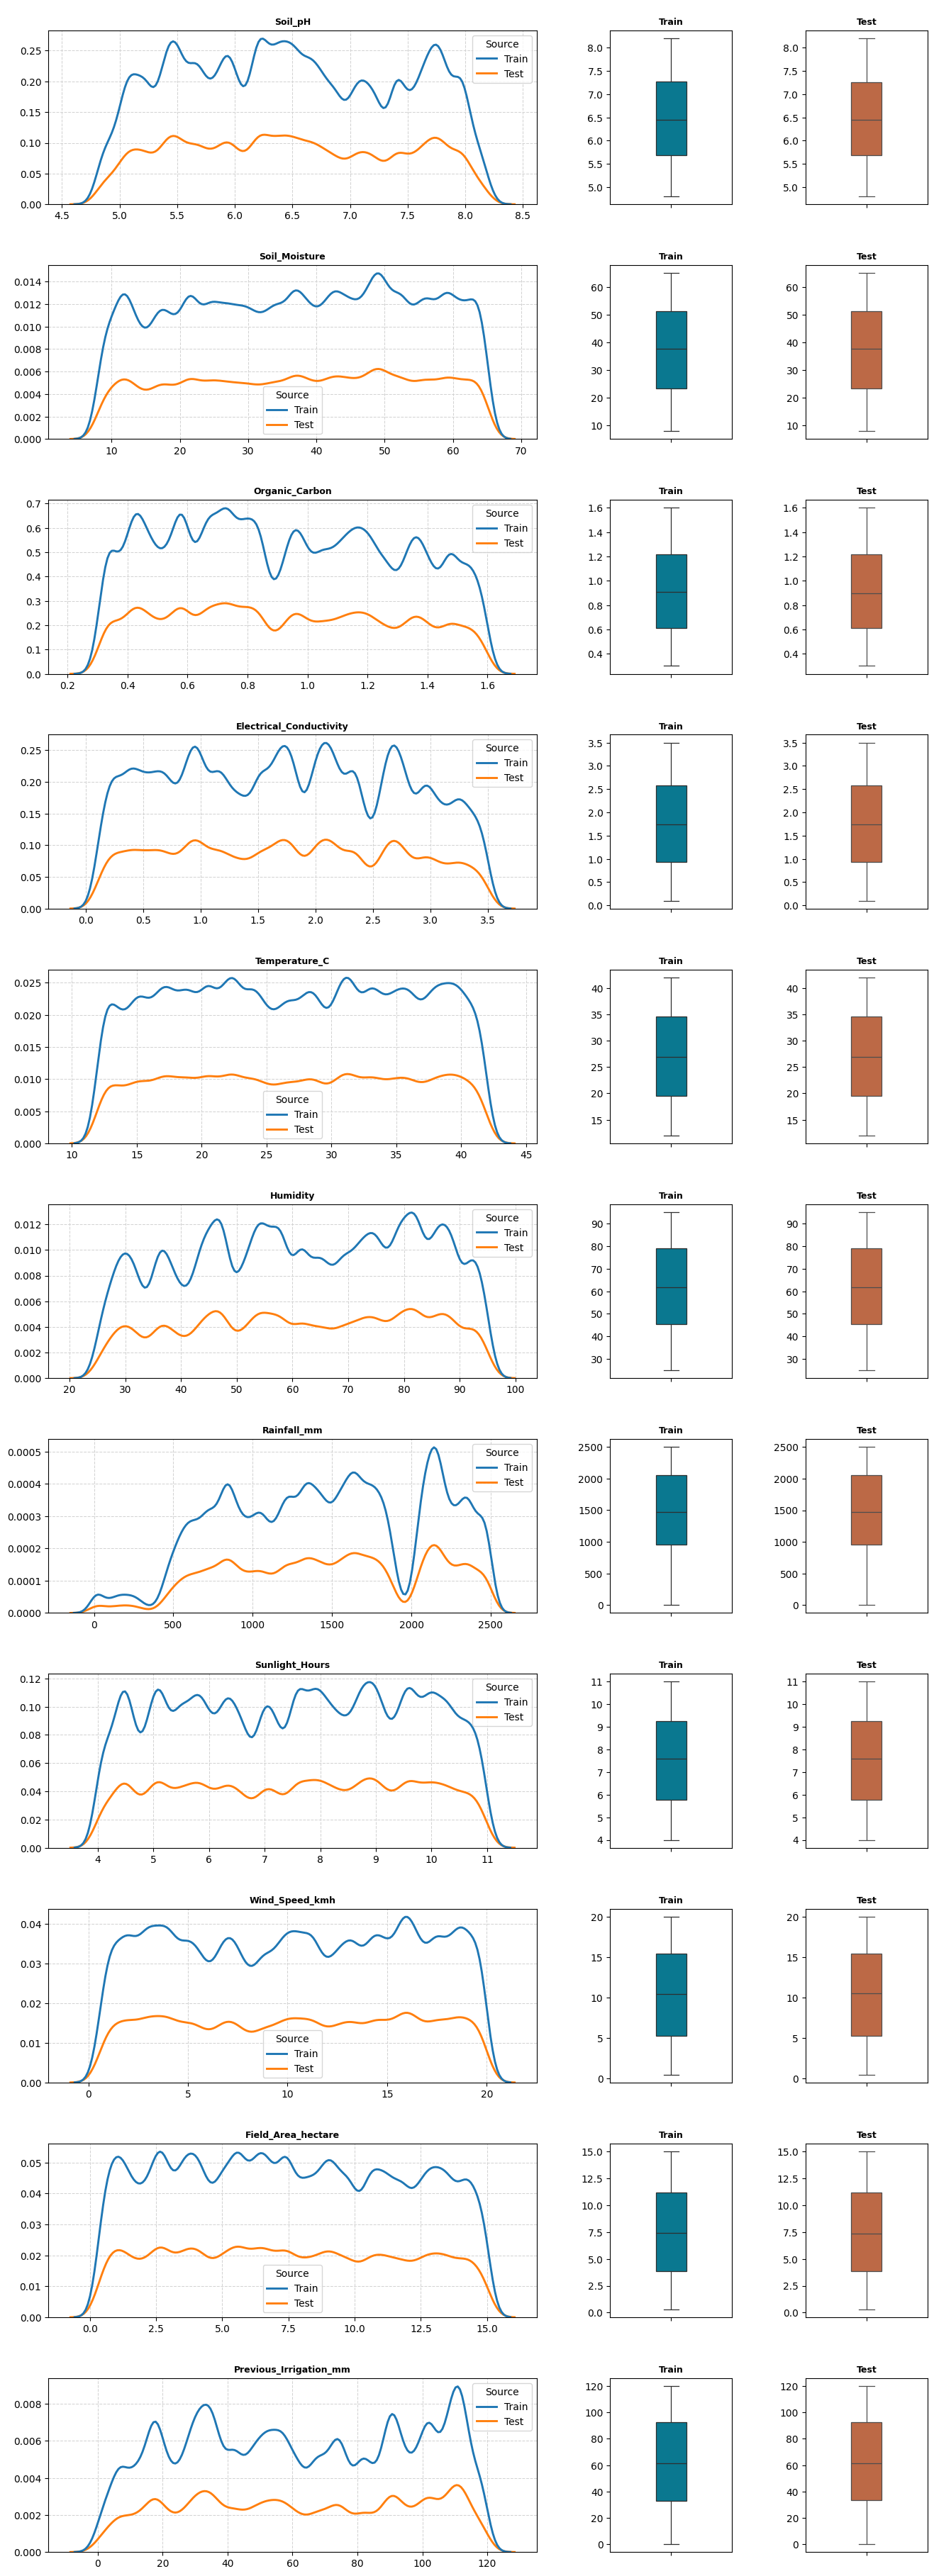

In [61]:
df = pd.concat([train[conts].assign(Source = 'Train'), 
                test[conts].assign(Source = 'Test')], 
               axis=0, ignore_index = True);

fig, axes = plt.subplots(len(conts), 3 ,figsize = (16, len(conts) * 4.2), 
                         gridspec_kw = {'hspace': 0.35, 'wspace': 0.3, 'width_ratios': [0.80, 0.20, 0.20]});

for i,col in enumerate(conts):
    ax = axes[i,0];
    sns.kdeplot(data = df[[col, 'Source']], x = col, hue = 'Source', ax = ax, linewidth = 2.1)
    ax.set_title(f"\n{col}",fontsize = 9, fontweight= 'bold');
    ax.grid(visible=True, which = 'both', linestyle = '--', color='lightgrey', linewidth = 0.75);
    ax.set(xlabel = '', ylabel = '');
    ax = axes[i,1];
    sns.boxplot(data = df.loc[df.Source == 'Train', [col]], y = col, width = 0.25,saturation = 0.90, linewidth = 0.90, fliersize= 2.25, color = '#037d97',
                ax = ax);
    ax.set(xlabel = '', ylabel = '');
    ax.set_title(f"Train",fontsize = 9, fontweight= 'bold');

    ax = axes[i,2];
    sns.boxplot(data = df.loc[df.Source == 'Test', [col]], y = col, width = 0.25, fliersize= 2.25,
                saturation = 0.6, linewidth = 0.90, color = '#E4591E',
                ax = ax); 
    ax.set(xlabel = '', ylabel = '');
    ax.set_title(f"Test",fontsize = 9, fontweight= 'bold');

plt.tight_layout()

In [48]:
def plot_count(df,columns,n_cols,hue):
    '''
    # Function to genear countplot
    df: total data
    columns: category variables
    n_cols: num of cols
    '''
    n_rows = (len(columns) - 1) // n_cols + 1
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(17, 4 * n_rows))
    ax = ax.flatten()
    
    for i, column in enumerate(columns):
        sns.countplot(data=df, x=column, ax=ax[i],hue=hue)

        # Titles
        ax[i].set_title(f'{column} Counts', fontsize=18)
        ax[i].set_xlabel(None, fontsize=16)
        ax[i].set_ylabel(None, fontsize=16)
        ax[i].tick_params(axis='x', rotation=10)

        for p in ax[i].patches:
            value = int(p.get_height())
            ax[i].annotate(f'{value:.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                           ha='center', va='bottom', fontsize=9)

    ylim_top = ax[i].get_ylim()[1]
    ax[i].set_ylim(top=ylim_top * 1.1)
    for i in range(len(columns), len(ax)):
        ax[i].axis('off')

    # fig.suptitle(plotname, fontsize=25, fontweight='bold')
    plt.tight_layout()
    plt.show()

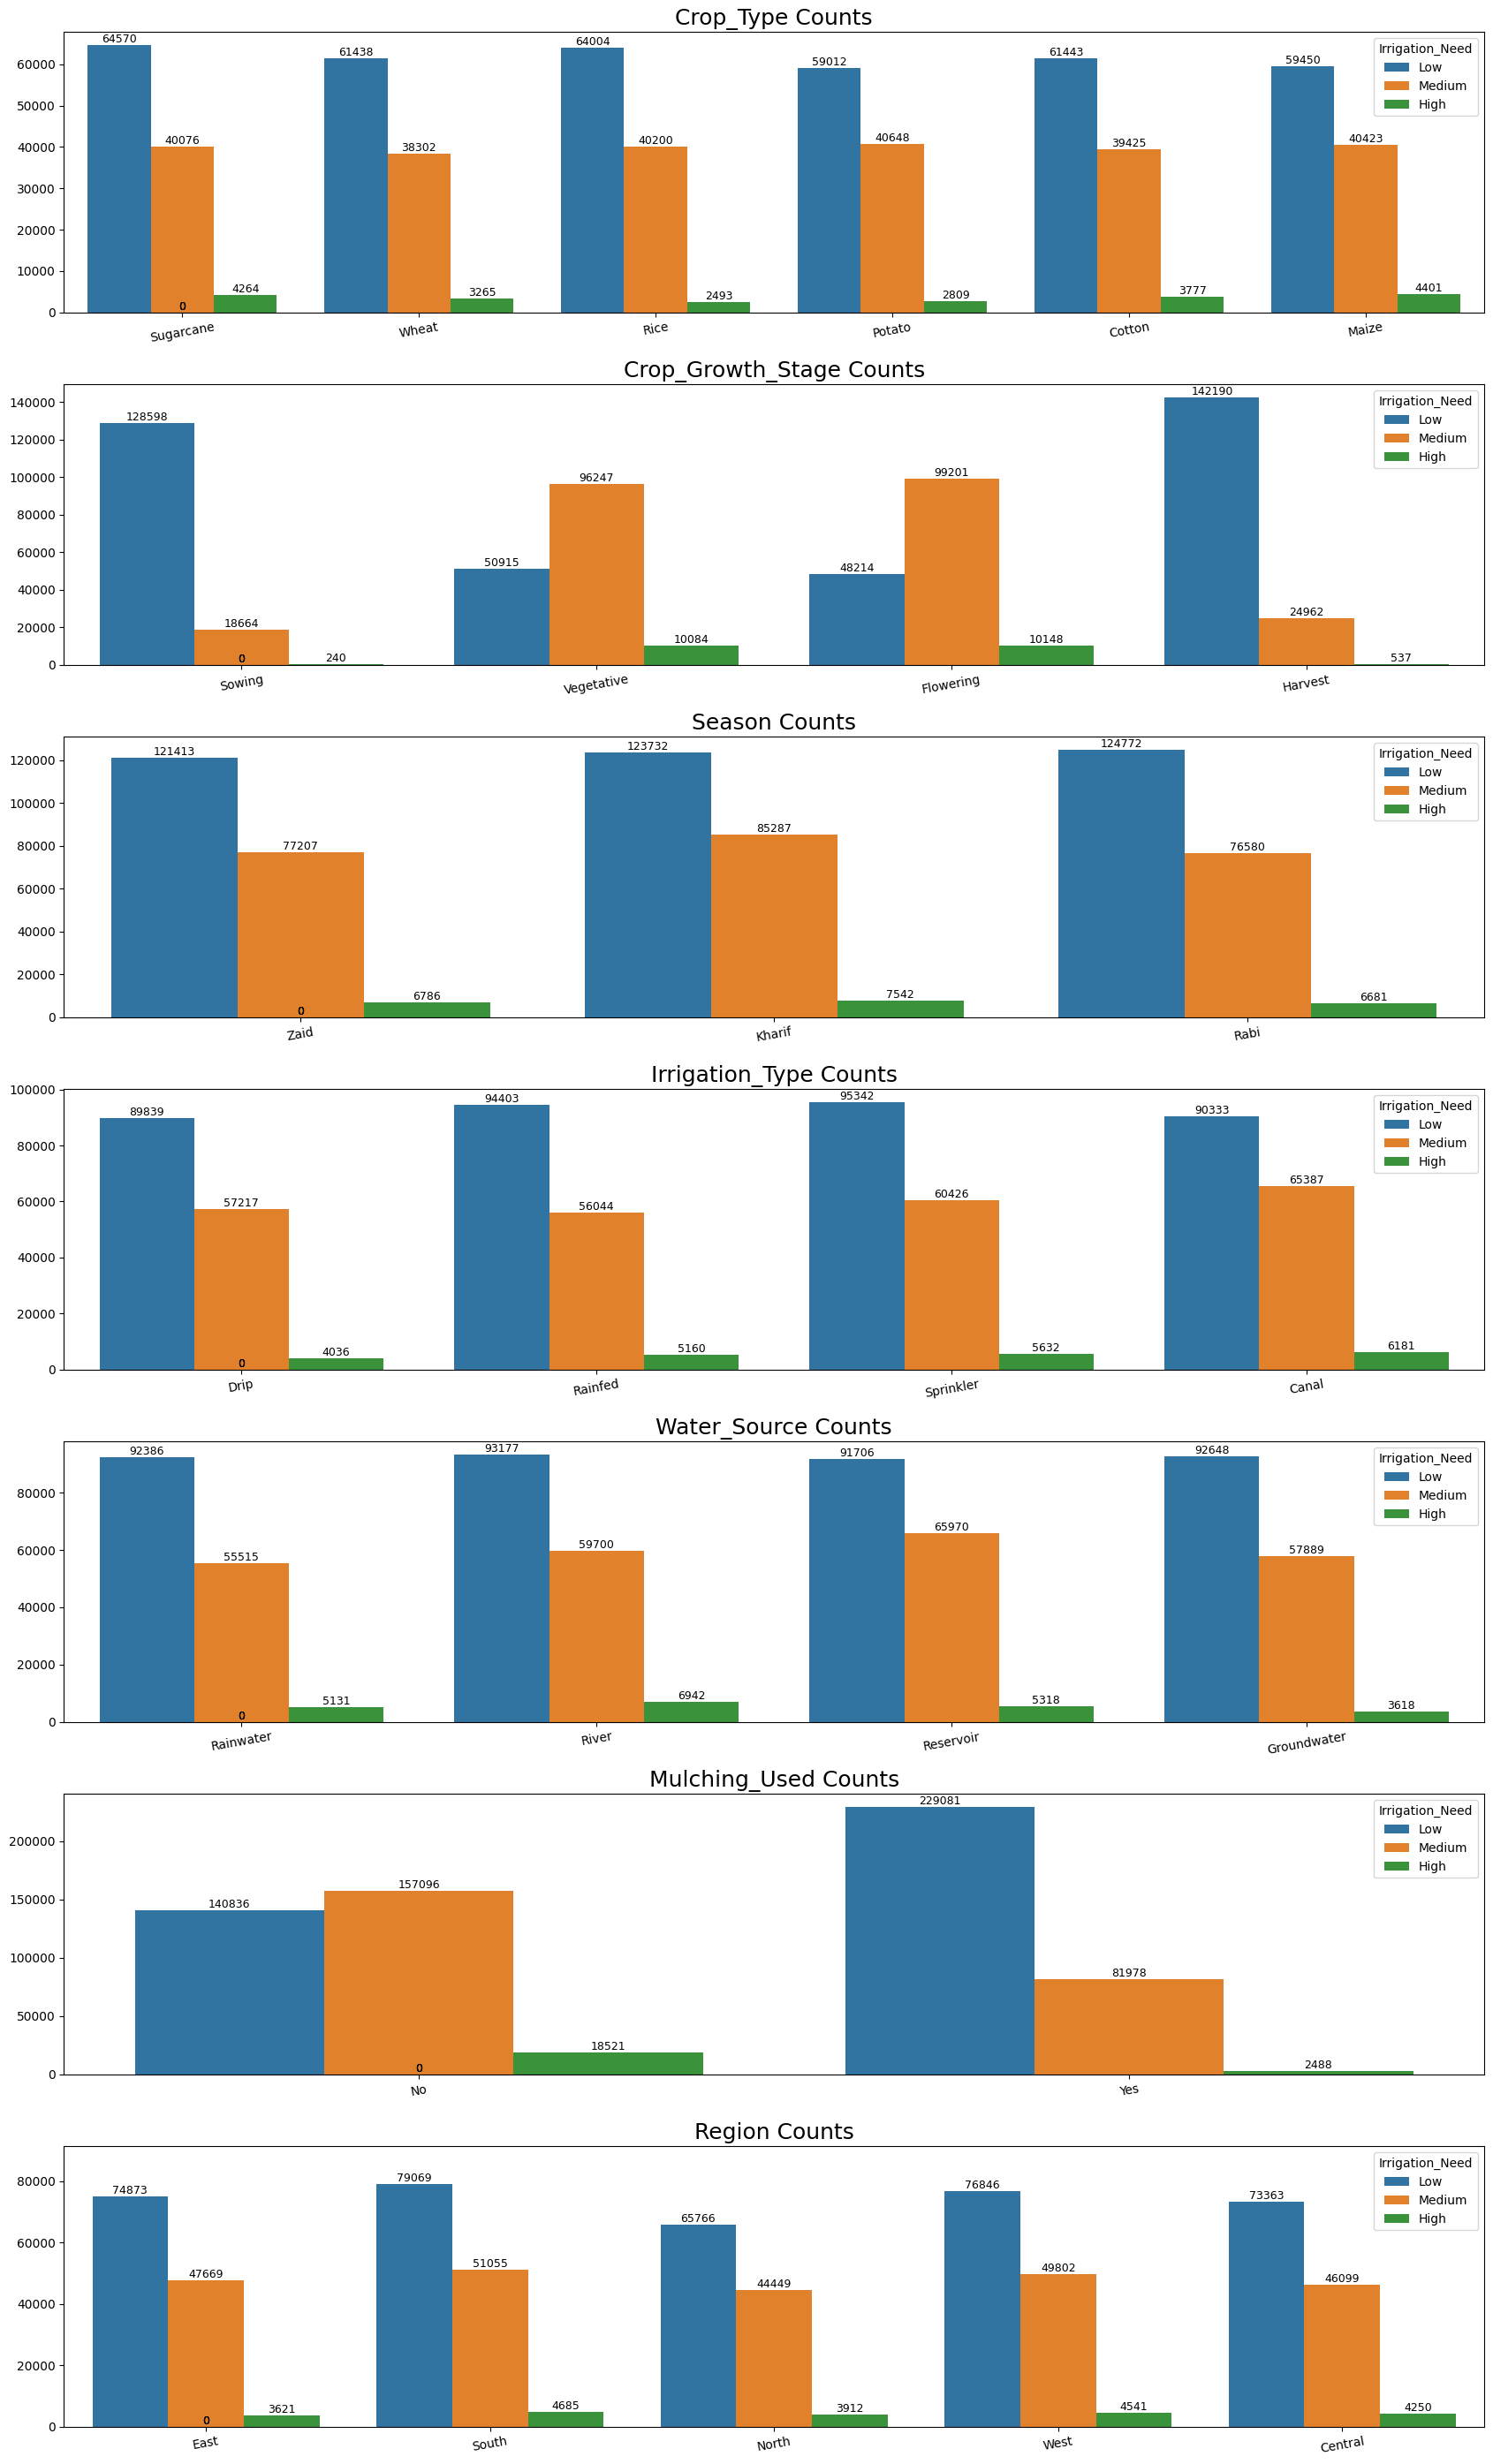

In [49]:
plot_count(train,cats,1,target)

In [62]:
low_medium_high_mapping = {
    "Low" : 0,
    "Medium" : 1,
    "High" : 2
}

growth_stage_mapping = {
    "Sowing" : 0,
    "Vegetative" : 1,
    "Flowering" : 2,
    "Harvest" : 3
}

inverse_low_medium_high_mapping = {
    0 : "Low",
    1 : "Medium",
    2 : "High"
}

yes_or_no_mapping = {
    "Yes" : 1,
    "No" : 0
}

train["Irrigation_Need"] = train["Irrigation_Need"].map(low_medium_high_mapping)

train["Mulching_Used"] = train["Mulching_Used"].map(yes_or_no_mapping)
train["Crop_Growth_Stage"] = train["Crop_Growth_Stage"].map(growth_stage_mapping)
test["Mulching_Used"] = test["Mulching_Used"].map(yes_or_no_mapping)
test["Crop_Growth_Stage"] = test["Crop_Growth_Stage"].map(growth_stage_mapping)

ordinal_cols = ['Crop_Type','Season', 'Irrigation_Type', 'Water_Source', 'Region']

ordinal_encoder = OrdinalEncoder()
train[ordinal_cols] = ordinal_encoder.fit_transform(train[ordinal_cols])
test[ordinal_cols] = ordinal_encoder.transform(test[ordinal_cols])

In [63]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,4.0,0,2.0,1.0,1.0,0.82,0,112.16,1.0,0
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.0,1,0.0,2.0,3.0,5.27,1,47.16,3.0,0
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,3.0,1,0.0,3.0,2.0,8.24,1,110.38,2.0,0
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,5.0,2,0.0,0.0,3.0,8.32,1,53.85,3.0,1
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,5.0,0,1.0,0.0,3.0,7.37,0,93.19,3.0,0


In [65]:
feature_cols = conts + cats

In [71]:
learningMetadata = {}

In [113]:
class learner():
    
    def __init__(self,df_train,df_test, target, model, selected_features, note, metric):
        self.X_train = df_train[selected_features]
        self.Y_train = df_train[target]
        self.X_test = df_test[selected_features]
        self.note = note
        self.metric = metric
        self.random_state = 42
        self.model = model
    
    def fit(self, trainingMode, params=None):
        skf = StratifiedKFold(shuffle=True, random_state=self.random_state)
        self.fold_accuracy = []
        self.model_preds_test = []
        self.model_preds_oof = []
        self.oof_y = []
        self.models = []
    
        for i,(train_index, test_index) in enumerate(skf.split(self.X_train, self.Y_train)):
            print('---------------------------------------------------------------')
            x_train_fold, x_test_fold = self.X_train.iloc[train_index], self.X_train.iloc[test_index]
            y_train_fold, y_test_fold = self.Y_train[train_index], self.Y_train[test_index]
        
            model_instance = self.model(**params) if params else self.model(random_state=self.random_state)
            model_instance.fit(x_train_fold, y_train_fold)
            
            model_oof_preds = model_instance.predict(x_test_fold)
            OOFaccScore = self.metric(y_test_fold,model_oof_preds)
            
            if trainingMode != 'tuning':
              self.models.append(model_instance)
              self.model_preds_test.append(model_instance.predict_proba(self.X_test))

              self.model_preds_oof.append(model_oof_preds)
              self.oof_y.append(y_test_fold)

            print(f"Fold, {i+1}, ==> {self.note} OOF score is ==> {OOFaccScore}")
            self.fold_accuracy.append(OOFaccScore)
    
        print('---------------------------------------------------------------')
        avgAcc = np.array(self.fold_accuracy).mean()
        print('Average OOF Accuracy of model is:', avgAcc)
        if trainingMode != 'tuning':
          learningMetadata[self.note] = {'avgOOFAcc': avgAcc}
          print('--------------------------------------------------------------')
          print(pd.DataFrame.from_dict(learningMetadata).T)
        else:
          return avgAcc
        
    def tune(self, no_trials, get_params):

      def tuning_objective(trial):
        params = get_params(trial)
        params['random_state'] = self.random_state
        return self.fit('tuning', params=params)

      self.tuning_study = optuna.create_study(direction='maximize')
      self.tuning_study.optimize(tuning_objective, n_trials=no_trials, show_progress_bar=True)
      best_model_params = self.tuning_study.best_trial.params
      print('Best model params are:', best_model_params)
      return best_model_params

In [134]:
def submit_preds(model, sample_submission, target, fileName):
  all_fold_predictions = np.array(model.model_preds_test)
  mean_predictions = all_fold_predictions.mean(axis=0)
  final_predictions = np.argmax(mean_predictions, axis=1)
  string_predictions = pd.Series(final_predictions).map(inverse_low_medium_high_mapping)
  sample_submission[target] = string_predictions.values
  sample_submission.to_csv(dataPath + fileName)

# Basic RF

In [ ]:
rf = learner(train,test,target,RandomForestClassifier,feature_cols,'BasicRF-Allcols', balanced_accuracy_score)
rf.fit()

---------------------------------------------------------------
Fold, 1, ==> BasicRF-Allcols OOF score is ==> 0.9601678252239846
---------------------------------------------------------------
Fold, 2, ==> BasicRF-Allcols OOF score is ==> 0.9602006332092067
---------------------------------------------------------------
Fold, 3, ==> BasicRF-Allcols OOF score is ==> 0.9609727793544778
---------------------------------------------------------------
Fold, 4, ==> BasicRF-Allcols OOF score is ==> 0.9586228318449814
---------------------------------------------------------------
Fold, 5, ==> BasicRF-Allcols OOF score is ==> 0.9609701215095532
---------------------------------------------------------------
Average OOF Accuracy of model is: 0.9601868382284409
-------------------------------------------------------------
                 avgOOFAcc
BasicRF-Allcols   0.960187


In [111]:
def rf_param_space(trial):
    """Defines the hyperparameter space for RandomForestClassifier."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, 50),
        'max_depth': trial.suggest_int('max_depth', 7, 30, 3),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 2000, log=True),
        'max_features':trial.suggest_int('max_features',2,16),
        'n_jobs': -1
    }
    return params

# Fine Tuning RF

In [116]:
# Create a new learner instance for tuning
rf_tuner = learner(train, test, target, RandomForestClassifier, feature_cols, 'TunedRF', balanced_accuracy_score)

# Start the tuning process
best_params = rf_tuner.tune(no_trials=50, get_params=rf_param_space)

# # Now you can train a new model with the best parameters
# rf_tuned = learner(train, test, target, RandomForestClassifier, feature_cols, 'TunedRF-Final', balanced_accuracy_score)
# rf_tuned.fit(trainingMode='production', params=best_params)

[I 2026-04-08 20:39:15,909] A new study created in memory with name: no-name-daaeb2e8-7a7d-4c64-ac93-0b82ad4d34a3
  0%|          | 0/50 [00:00<?, ?it/s]

---------------------------------------------------------------
Fold, 1, ==> TunedRF OOF score is ==> 0.9537852217981291
---------------------------------------------------------------
Fold, 2, ==> TunedRF OOF score is ==> 0.9542878982318294
---------------------------------------------------------------
Fold, 3, ==> TunedRF OOF score is ==> 0.9546699302563959
---------------------------------------------------------------
Fold, 4, ==> TunedRF OOF score is ==> 0.9536686974966858
---------------------------------------------------------------


Best trial: 0. Best value: 0.953687:   2%|▏         | 1/50 [15:17<12:29:18, 917.52s/it]

Fold, 5, ==> TunedRF OOF score is ==> 0.9520208393301696
---------------------------------------------------------------
Average OOF Accuracy of model is: 0.9536865174226419
[I 2026-04-08 20:54:33,431] Trial 0 finished with value: 0.9536865174226419 and parameters: {'n_estimators': 800, 'max_depth': 25, 'min_samples_leaf': 1826, 'max_features': 13}. Best is trial 0 with value: 0.9536865174226419.
---------------------------------------------------------------
Fold, 1, ==> TunedRF OOF score is ==> 0.9604149091146313
---------------------------------------------------------------
Fold, 2, ==> TunedRF OOF score is ==> 0.9616306635370734
---------------------------------------------------------------
Fold, 3, ==> TunedRF OOF score is ==> 0.9609670511081346
---------------------------------------------------------------
Fold, 4, ==> TunedRF OOF score is ==> 0.9613509896040999
---------------------------------------------------------------


Best trial: 1. Best value: 0.960772:   4%|▍         | 2/50 [19:54<7:12:41, 540.86s/it] 

...

Best trial: 26. Best value: 0.9625:  74%|███████▍  | 37/50 [21:36:55<4:01:18, 1113.75s/it]

Fold, 5, ==> TunedRF OOF score is ==> 0.9417539697678272
---------------------------------------------------------------
Average OOF Accuracy of model is: 0.9416770263945142
[I 2026-04-09 18:16:11,205] Trial 36 finished with value: 0.9416770263945142 and parameters: {'n_estimators': 600, 'max_depth': 25, 'min_samples_leaf': 1044, 'max_features': 10}. Best is trial 26 with value: 0.962499895988411.
---------------------------------------------------------------
Fold, 1, ==> TunedRF OOF score is ==> 0.9609196325652677
---------------------------------------------------------------


Best trial: 26. Best value: 0.9625:  74%|███████▍  | 37/50 [21:47:21<7:39:20, 2120.04s/it]

[W 2026-04-09 18:26:37,236] Trial 37 failed with parameters: {'n_estimators': 750, 'max_depth': 19, 'min_samples_leaf': 17, 'max_features': 15} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/vithanage/Projects/Learning/ML/venv/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/mq/zhbbfycx7_q6dvlx0x8wwkww0000gn/T/ipykernel_94513/2956036218.py", line 56, in tuning_objective
    return self.fit('tuning', params=params)
  File "/var/folders/mq/zhbbfycx7_q6dvlx0x8wwkww0000gn/T/ipykernel_94513/2956036218.py", line 26, in fit
    model_instance.fit(x_train_fold, y_train_fold)
  File "/Users/vithanage/Projects/Learning/ML/venv/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/vithanage/Projects/Learning/ML/venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py", lin

KeyboardInterrupt: 

In [ ]:
#  Trial 9 finished with value: 0.9614904608607983 and parameters: {'n_estimators': 150, 'max_depth': 16, 'min_samples_leaf': 25, 'max_features': 7}. Best is trial 9 with value: 0.9614904608607983.
# Trial 16 finished with value: 0.962359054926783 and parameters: {'n_estimators': 400, 'max_depth': 16, 'min_samples_leaf': 20, 'max_features': 13}. Best is trial 16 with value: 0.962359054926783.
# Trial 19 finished with value: 0.9624602534298049 and parameters: {'n_estimators': 400, 'max_depth': 22, 'min_samples_leaf': 10, 'max_features': 14}. Best is trial 19 with value: 0.9624602534298049.
# Trial 26 finished with value: 0.962499895988411 and parameters: {'n_estimators': 500, 'max_depth': 19, 'min_samples_leaf': 10, 'max_features': 15}. Best is trial 26 with value: 0.962499895988411.

In [118]:
best_params = {'n_estimators': 500, 'max_depth': 19, 'min_samples_leaf': 10, 'max_features': 15, 'n_jobs': -1, 'random_state': 42}
rf = learner(train,test,target,RandomForestClassifier,feature_cols,'TunedRF-Allcols-5Fold', balanced_accuracy_score)
rf.fit('None', params=best_params)

---------------------------------------------------------------
Fold, 1, ==> TunedRF-Allcols-5Fold OOF score is ==> 0.9613524073316425
---------------------------------------------------------------
Fold, 2, ==> TunedRF-Allcols-5Fold OOF score is ==> 0.9634411557118496
---------------------------------------------------------------
Fold, 3, ==> TunedRF-Allcols-5Fold OOF score is ==> 0.9627244001316848
---------------------------------------------------------------
Fold, 4, ==> TunedRF-Allcols-5Fold OOF score is ==> 0.9627292114397142
---------------------------------------------------------------
Fold, 5, ==> TunedRF-Allcols-5Fold OOF score is ==> 0.9622523053271634
---------------------------------------------------------------
Average OOF Accuracy of model is: 0.962499895988411
--------------------------------------------------------------
                       avgOOFAcc
BasicRF-Allcols         0.960187
TunedRF-Allcols-5Fold   0.962500


In [135]:
submit_preds(rf, sample_submission, target, 'TunedRF5Fold.csv')